# Setup

## OpenAI Key 등록
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [2]:
from dotenv import load_dotenv

load_dotenv()


True

# Vector DB

## Embedding

In [1]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## ChromaDB
> 기존에 생성된 VectorDB 접속 

In [24]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma(
    collection_name="rag_keywords", # 컬렉션 이름
    embedding_function=embeddings,
    persist_directory="./chroma_rag_keywords" # 기존 영구 저장 경로
)

print("Chroma VectorStore가 생성되었습니다.")

Chroma VectorStore가 생성되었습니다.


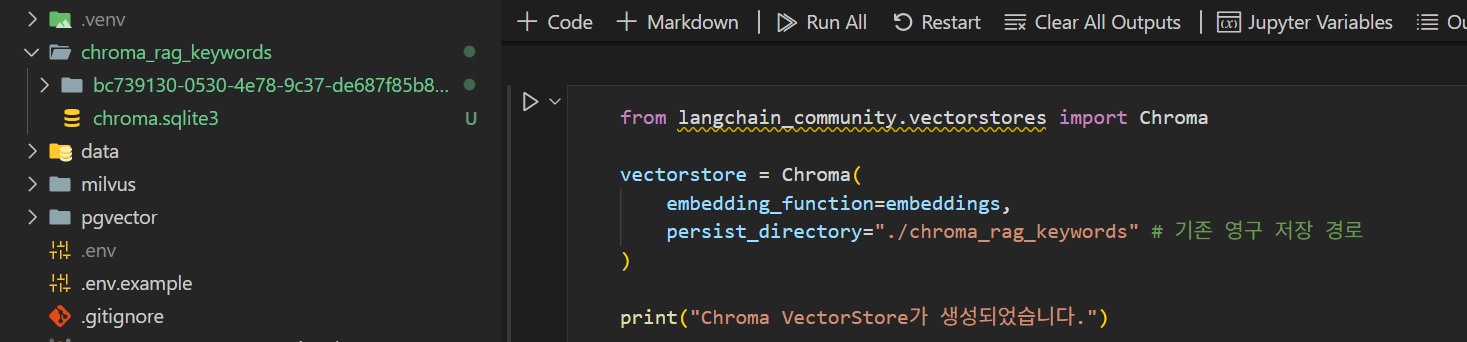

In [25]:
stats = vectorstore._collection.count()

print(f"현재 문서 수: {stats}")

현재 문서 수: 11


# [Retriever](https://python.langchain.com/docs/how_to/#retrievers)
- Retrieval Augmented Generation (RAG)에서 `검색도구(Retrievers)` 는 벡터 저장소에서 문서를 검색하는 도구입니다.
- LangChain은 간단한 의미 검색도구부터 성능 향상을 위해 고려된 다양한 검색 알고리즘을 지원합니다.

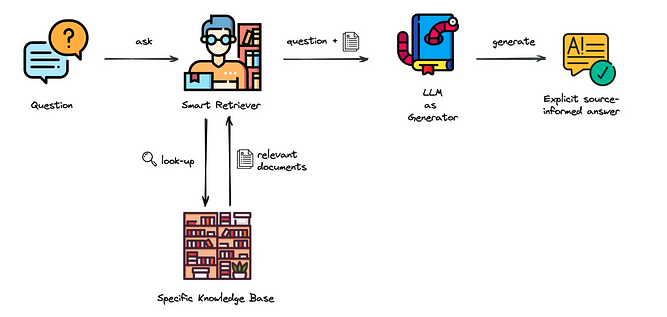

## Retriever 생성

In [26]:
# 데이터베이스를 검색기로 사용하기 위해 retriever 변수에 할당
retriever = vectorstore.as_retriever()

## [다중 쿼리 검색기](https://wikidocs.net/234109)
- 거리 기반 벡터 데이터베이스 검색은 고차원 공간에서의 쿼리 임베딩(표현)과 '거리'를 기준으로 유사한 임베딩을 가진 문서를 찾는 방식입니다. 하지만 쿼리의 세부적인 차이나 임베딩이 데이터의 의미를 제대로 포착하지 못할 경우, 검색 결과가 달라질 수 있습니다. 또한, 이를 수동으로 조정하는 프롬프트 엔지니어링이나 튜닝 작업은 번거로울 수 있습니다.
- 이런 문제를 해결하기 위해, `MultiQueryRetriever` 는 주어진 사용자 입력 쿼리에 대해 다양한 관점에서 여러 쿼리를 자동으로 생성하는 LLM(Language Learning Model)을 활용해 프롬프트 튜닝 과정을 자동화합니다.
- 이 방식은 각각의 쿼리에 대해 관련 문서 집합을 검색하고, 모든 쿼리를 아우르는 고유한 문서들의 합집합을 추출해, 잠재적으로 관련된 더 큰 문서 집합을 얻을 수 있게 해줍니다.
- 여러 관점에서 동일한 질문을 생성함으로써, `MultiQueryRetriever` 는 거리 기반 검색의 제한을 일정 부분 극복하고, 더욱 풍부한 검색 결과를 제공할 수 있습니다.

### LLM

In [27]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### MultiQueryRetriever
- `MultiQueryRetriever`는 LangChain의 고급 검색(retrieval) 기법 중 하나로, `사용자의 질문을 LLM을 통해 여러 형태로 변형(paraphrase)` 하여 더 풍부하고 포괄적인 검색 결과를 얻기 위해 사용됩니다.

즉, "하나의 질문을 여러 개의 의미적으로 유사한 쿼리로 확장" 해서 `벡터 스토어나 검색엔진에서 더 다양한 문서를 가져오는 역할`을 합니다.

In [28]:
from langchain.retrievers.multi_query import MultiQueryRetriever

# MultiQueryRetriever를 언어 모델을 사용하여 초기화합니다.
multiquery_retriever = MultiQueryRetriever.from_llm(
    # 벡터 데이터베이스의 retriever와 언어 모델을 전달합니다.
    retriever=retriever,
    llm=llm,
)


### 디버깅
- 아래는 다중 쿼리를 생성하는 중간 과정을 디버깅하기 위하여 실행하는 코드입니다.
- 먼저 `"langchain.retrievers.multi_query"` 로거를 가져옵니다.
- 이는 `logging.getLogger()` 함수를 사용하여 수행됩니다. 그 다음, 이 로거의 로그 레벨을 `INFO`로 설정하여, `INFO` 레벨 이상의 로그 메시지만 출력되도록 할 수 있습니다.

In [29]:
# 쿼리에 대한 로깅 설정
import logging

logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)


- 이 코드는 `retriever_from_llm` 객체의 `invoke()` 메서드를 사용하여 주어진 `question`과 관련된 문서를 검색합니다.
- 검색된 문서들은 `unique_docs`라는 변수에 저장되며, 이 변수의 길이를 확인함으로써 검색된 관련 문서의 총 개수를 알 수 있습니다.
- 이 과정을 통해 사용자의 질문에 대한 관련 정보를 효과적으로 찾아내고 그 양을 파악할 수 있습니다.

In [30]:
# 질문을 정의합니다.
question = "TF IDF 에 대하여 알려줘"
# 문서 검색
relevant_docs = multiquery_retriever.invoke(input=question)

# 검색된 고유한 문서의 개수를 반환합니다.
print(f"""
    ==============================
    검색된 문서 개수: {len(relevant_docs)}
    =============================="""
)

if relevant_docs:
    # 검색된 문서의 내용을 출력합니다.
    print(relevant_docs[0].page_content)


INFO:langchain.retrievers.multi_query:Generated queries: ['TF-IDF가 무엇인지 간단히 설명해줘.', 'TF-IDF의 정의와 수학적 계산 방법, 그리고 실무에서의 활용 사례를 자세히 알려줘.', '검색 엔진에서 TF-IDF가 어떻게 작동하는지 사례를 통해 설명해줘.']



    검색된 문서 개수: 6
정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema

정의: 스키마는 데이터베이스나 파일의 구조를 정의하는 것으로, 데이터가 어떻게 저장되고 조직되는지에 대한 청사진을 제공합니다.
예시: 관계형 데이터베이스의 테이블 스키마는 열 이름, 데이터 타입, 키 제약 조건 등을 정의합니다.
연관키워드: 데이터베이스, 데이터 모델링, 데이터 관리

DataFrame


## 간단한 RAG 예제

### PromptTemplate

In [31]:
from langchain.prompts import PromptTemplate

prompt_template = """
    다음 문서를 바탕으로 질문에 답변해주세요.
    
    문서:
    {context}
    
    질문: {question}
    
    답변: 문서의 내용을 바탕으로 정확하고 자세하게 답변해주세요.
"""
    
prompt = PromptTemplate.from_template(
    template=prompt_template
)

### LLM

In [32]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### RetrievalQA

In [34]:
from langchain.chains import RetrievalQA

# RAG (Retrieval-Augmented Generation) 시스템 생성
rag_system = RetrievalQA.from_chain_type(
    llm=llm,  # 사용할 LLM 모델 (예: ChatOpenAI, ChatAnthropic 등)
    
    chain_type="stuff",  # 문서 처리 방식: "stuff"는 검색된 모든 문서를 한번에 LLM에 전달
                         # 다른 옵션: "map_reduce", "refine", "map_rerank"
    
    retriever=multiquery_retriever, # 다중 쿼리 검색기 적용 
    
    return_source_documents=True,  # 답변과 함께 참조한 원본 문서도 반환 (출처 확인 가능)
    
    chain_type_kwargs={"prompt": prompt}  # 커스텀 프롬프트 템플릿 적용
)

In [35]:
def test_rag_system(rag_system, questions):
    """RAG 시스템을 테스트하는 함수"""
    for question in questions:
        print(f"\n질문: {question}")
        
        # 검색된 문서들 가져오기
        retriever = rag_system.retriever # RAG 시스템의 검색기
        docs = retriever.invoke(question) # 관련 문서 검색
        
        print("관련 문서:")
        for i, doc in enumerate(docs, 1):
            print(f"{i}. {doc.page_content[:100]}...")
        
        print("=" * 50)

In [36]:
# 테스트 질문들
test_questions = [
    "벡터 데이터베이스의 역할은 무엇인가요?"
]

test_rag_system(rag_system, test_questions)


질문: 벡터 데이터베이스의 역할은 무엇인가요?


INFO:langchain.retrievers.multi_query:Generated queries: ['벡터 데이터베이스가 문서 검색에서 수행하는 핵심 역할은 무엇이며, 이를 가능하게 하는 주요 구성 요소는 무엇인가요?', '문서 검색 관점에서 벡터 데이터베이스의 기능과 작동 원리는 무엇이며, 임베딩 품질과 인덱스 설계가 검색 결과에 어떤 영향을 주나요?', '벡터 데이터베이스의 역할은 무엇이고, 거리 기반 유사도 검색의 한계를 극복하기 위한 방법에는 어떤 것들이 있나요?']


관련 문서:
1. 정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는 자연어 처리에서 데이터를 전처리하는 데 사용됩니다.
예시: "I love programming."이라는 문장...
2. Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을 넘어서 그 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
예시: 사용자가 "태...
3. 정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: ...
4. 정의: 키워드 검색은 사용자가 입력한 키워드를 기반으로 정보를 찾는 과정입니다. 이는 대부분의 검색 엔진과 데이터베이스 시스템에서 기본적인 검색 방식으로 사용됩니다.
예시: 사용자...
5. 정의: Word2Vec은 단어를 벡터 공간에 매핑하여 단어 간의 의미적 관계를 나타내는 자연어 처리 기술입니다. 이는 단어의 문맥적 유사성을 기반으로 벡터를 생성합니다.
예시: W...
